In [1]:
from __future__ import annotations

from collections.abc import Iterator, Sequence
import functools
import itertools
from pathlib import Path

import pandas as pd

from sta.benchmarks.plot_utils import *

In [2]:
ROOT_DIR = Path('../')
OUTPUT_DIR = ROOT_DIR / 'data' / 'segmentation_element'

In [3]:
def get_csv_path(run: RunCombination):
    def percent_digits(x: float):
        return str(x)[2:4].ljust(2, '0')

    base_dir = Path(str(OUTPUT_DIR) + "_" + str(run.num_points) + "_storage")
    if not base_dir.exists():
        msg = f"Cannot find base directory {base_dir}"
        raise ValueError(msg)

    run_dir = base_dir / f'perf_label_queries_{run.num_commits}_b_{percent_digits(run.branch_prob)}_c_{percent_digits(run.create_prob)}_d_{percent_digits(run.delete_prob)}_i_{run.num_init_labels}_seed_{run.seed}_delta_{int(run.use_delta)}'
    return run_dir / 'history.csv'

def get_run_data(run: RunCombination):
    path = get_csv_path(run)
    df = pd.read_csv(path)
    df["num_init_labels"] = run.num_init_labels
    df["num_points"] = run.num_points
    df["delete_prob"] = run.delete_prob
    df["use_delta"] = run.use_delta
    return df

def iter_runs(
    num_commits: int = 500,
    all_num_points: Sequence[int] = (500,),
    all_create_probs: Sequence[float] = (0.35,),
    all_delete_probs: Sequence[float] = (0.10, 0.20, 0.30),
    all_num_init_labels: Sequence[int] = (0,),
    all_seeds: Sequence[int] = (1, 2, 3),
    all_use_deltas: Sequence[bool] = (False, True),
):
    for num_points in all_num_points:
        for num_init_labels in all_num_init_labels:
            for create_prob in all_create_probs:
                for delete_prob in all_delete_probs:
                    for seed in all_seeds:
                        for use_delta in all_use_deltas:
                            yield RunCombination(
                                num_commits=num_commits,
                                num_init_labels=num_init_labels,
                                num_points=num_points,
                                branch_prob=0.00,
                                create_prob=create_prob,
                                delete_prob=delete_prob,
                                entity_prob=0.20,
                                seed=seed,
                                use_delta=use_delta,
                            )

def get_plot_data(runs: Iterator[RunCombination]):
    runs_lst = list(runs)
    plot_df = pd.concat(get_run_data(run) for run in runs_lst if get_csv_path(run).exists())
    bin_params = max(runs_lst, key=lambda r: (r.create_prob - r.delete_prob)).get_params()

    return plot_df, bin_params

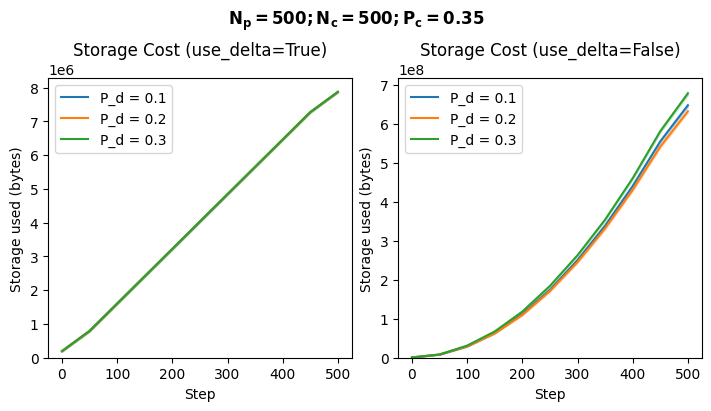

In [4]:
def get_title_for_combination(params: ParametersGroupByDeleteProb):
    return r'$\mathbf{' + f'N_p = {params.num_points}; N_c = {params.num_commits}; P_c = {params.create_prob}' + r'}$'

def get_row_plot_fns_for_repository(runs: Iterator[RunCombination]):
    plot_df, _ = get_plot_data(runs)

    return {
        'Storage Cost (use_delta=True)': functools.partial(
            plot_storage_cost,
            plot_df[plot_df["use_delta"] == 1],
            label_type="element",
            vary="delete_prob",
        ),
        'Storage Cost (use_delta=False)': functools.partial(
            plot_storage_cost,
            plot_df[plot_df["use_delta"] == 0],
            label_type="element",
            vary="delete_prob",
        ),
    }


apply_plot_fns(
    {
        get_title_for_combination(params): get_row_plot_fns_for_repository(runs)
        for params, runs in itertools.groupby(iter_runs(), lambda x: x.get_params_group_by_delete_prob())
    }.items(),
    colwidth=3,
    rowheight=3,
    share_legend=False,
).show()